# TextGrad Optimization & Ablation Study

End-to-end results for the LLM-based VC decision pipeline.

| Sections | Content |
|----------|---------|
| 1–5 | TextGrad training: validation metrics, convergence, prompt evolution |
| 6 | Ablation: Random · Single Agent · Multi-analyst · TextGrad |
| 7–8 | LLM-as-judge: reasoning quality scored on 6 dimensions |

Run cells top-to-bottom after any new experiment. To pin a specific judge evaluation run, set `RUN_TIMESTAMP` in the config cell below.

In [ ]:
import json
import difflib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PROJECT_ROOT = Path("..").resolve()
TG_DIR    = PROJECT_ROOT / "results" / "textgrad_validation"
ABL_DIR   = PROJECT_ROOT / "results" / "ablation"
JUDGE_DIR = PROJECT_ROOT / "results" / "judge_evaluation"

In [ ]:
# ── Run selection ─────────────────────────────────────────────────────────────
# Leave as None to use the most recent run (via the `latest` symlink).
# Set to a timestamp to pin a specific run, e.g. "2026-06-21_10-00-00_s42".
# All three share the same value when launched via run_experiments.py.
TG_TIMESTAMP  = None   # TextGrad run
ABL_TIMESTAMP = None   # Ablation run
RUN_TIMESTAMP = None   # Judge evaluation run

def _list_runs(label, runs_dir, selected_ts):
    runs = sorted(
        [p.name for p in runs_dir.glob("*/") if p.is_dir()],
        reverse=True,
    ) if runs_dir.exists() else []
    print(f"{label}:")
    if not runs:
        print("  (no runs yet)")
    else:
        for ts in runs:
            marker = "  ← selected (most recent)" if (selected_ts is None and ts == runs[0]) \
                     else ("  ← selected" if ts == selected_ts else "")
            print(f"  {ts}{marker}")
    print()

_list_runs("TextGrad runs", TG_DIR  / "runs", TG_TIMESTAMP)
_list_runs("Ablation runs", ABL_DIR / "runs", ABL_TIMESTAMP)
_list_runs("Judge runs",    JUDGE_DIR / "runs", RUN_TIMESTAMP)

## 1. Load TextGrad training results

In [ ]:
def _tg_dir():
    """Resolve the TextGrad results directory for the selected run."""
    if TG_TIMESTAMP is not None:
        d = TG_DIR / "runs" / TG_TIMESTAMP
    else:
        latest = TG_DIR / "latest"
        d = latest.resolve() if latest.exists() else TG_DIR
    if not d.exists():
        print(f"⚠  TextGrad run not found: {d}")
    return d

def load_metrics():
    path = _tg_dir() / "metrics_per_step.jsonl"
    if not path.exists():
        return []
    rows = []
    for line in path.read_text().splitlines():
        if line.strip():
            rec = json.loads(line)
            if 'val_metrics' in rec:  # skip per-step training records; keep validation records only
                flat = {**rec, **rec.pop('val_metrics')}
                rows.append(flat)
    print(f"TextGrad metrics : {path}  ({len(rows)} validation steps)")
    return rows

def load_prompts():
    prompts = {}
    d = _tg_dir()
    if d.exists():
        for f in sorted(d.glob("prompt_step_*.txt")):
            step = int(f.stem.split("_")[-1])
            prompts[step] = f.read_text()
    return prompts

def load_final():
    out = {}
    d = _tg_dir()
    p = d / "final_metrics.json"
    if p.exists():
        out['metrics'] = json.loads(p.read_text())
    p = d / "final_synthesizer_prompt.txt"
    if p.exists():
        out['prompt'] = p.read_text()
    p = d / "data_splits.json"
    if p.exists():
        out['splits'] = json.loads(p.read_text())
    return out

metrics_data = load_metrics()
prompts      = load_prompts()
final        = load_final()

print(f"TextGrad dir     : {_tg_dir()}")
print(f"Prompt snapshots : {len(prompts)}")
if 'splits' in final:
    s = final['splits']
    print(f"Train / val sizes: {s.get('n_train')} / {s.get('n_val')}  (seed={s.get('seed')})")

## 2. Validation metrics per training step

In [ ]:
if metrics_data:
    df = pd.DataFrame(metrics_data)
    steps = df['step'].tolist() if 'step' in df.columns else list(df.index)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("TextGrad: Validation Metrics per Training Step", fontweight='bold')

    def plot(ax, cols, title):
        for col, marker in zip(cols, 'osDv'):
            if col in df.columns:
                ax.plot(steps, df[col], marker=marker, linewidth=2, label=col)
        ax.set_xlabel('Training step')
        ax.set_ylabel('Score')
        ax.set_title(title)
        ax.set_xticks(steps)
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(alpha=0.3)

    plot(axes[0, 0], ['p_10', 'p_20', 'p_30'],                          'Precision @K')
    plot(axes[0, 1], ['balanced_accuracy', 'precision', 'recall', 'f1'], 'Classification Metrics')
    plot(axes[1, 0], ['auroc'],                                          'AUROC')

    if prompts:
        psteps  = sorted(prompts.keys())
        lengths = [len(prompts[s]) for s in psteps]
        axes[1, 1].plot(psteps, lengths, 'o-', color='tab:purple', linewidth=2)
        axes[1, 1].set_xlabel('Training step')
        axes[1, 1].set_ylabel('Characters')
        axes[1, 1].set_title('Synthesizer Prompt Length')
        axes[1, 1].set_xticks(psteps)
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    table_cols = [c for c in ['step', 'auroc', 'balanced_accuracy', 'precision', 'recall', 'f1', 'p_10', 'p_20', 'p_30'] if c in df.columns]
    display(df[table_cols].round(4))
else:
    print("⚠️  No metrics found. Run: python experiments/run_textgrad.py --n_train 5 --n_val 5")

## 3. Prompt evolution

In [90]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    print(f"Steps: {steps}")
    print(f"Initial length : {len(prompts[steps[0]])} chars")
    print(f"Final length   : {len(prompts[steps[-1]])} chars\n")

    for i in range(len(steps) - 1):
        a, b = prompts[steps[i]], prompts[steps[i+1]]
        diff = list(difflib.unified_diff(a.splitlines(), b.splitlines(), lineterm=''))
        adds = sum(1 for l in diff if l.startswith('+') and not l.startswith('+++'))
        dels = sum(1 for l in diff if l.startswith('-') and not l.startswith('---'))
        changes = [l for l in diff if l.startswith(('+','-'))
                   and not l.startswith(('+++','---'))]
        print(f"Step {steps[i]} → {steps[i+1]}:  +{adds} lines  -{dels} lines")
        for c in changes[:3]:
            sym = '➕' if c[0] == '+' else '➖'
            print(f"   {sym} {c[1:80]}")
        print()
else:
    print("No prompt snapshots found yet.")


Steps: [0, 1, 2, 3]
Initial length : 2665 chars
Final length   : 2040 chars

Step 0 → 1:  +8 lines  -4 lines
   ➖ You are the chief analyst at a venture capital firm. You receive evaluation rep
   ➕ You are the chief analyst at a venture capital firm. You receive evaluation rep
   ➖ Please provide a detailed analysis of the potential benefits and drawbacks of t

Step 1 → 2:  +8 lines  -34 lines
   ➖ You are the chief analyst at a venture capital firm. You receive evaluation rep
   ➖ 
   ➖ Please provide a detailed analysis of the potential benefits and drawbacks of t

Step 2 → 3:  +9 lines  -4 lines
   ➖ You are the chief analyst at a venture capital firm. You receive evaluation rep
   ➖ OUTPUT FORMAT: 
   ➖ Respond with valid JSON only — no markdown, no preamble: 



## 4. Initial vs. final prompt (full diff)

In [91]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    initial, final_p = prompts[steps[0]], prompts[steps[-1]]
    diff = difflib.unified_diff(
        initial.splitlines(keepends=True),
        final_p.splitlines(keepends=True),
        fromfile=f'step_{steps[0]}',
        tofile=f'step_{steps[-1]}',
    )
    print(''.join(diff))
else:
    print("Need at least 2 prompt snapshots.")


--- step_0
+++ step_3
@@ -1,34 +1,17 @@
-You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation.
+You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation. Please provide a comprehensive analysis of the potential benefits and drawbacks of the investment, including but not limited to the competitive advantage, market trends, potential risks, and quantitative metrics such as revenue growth rate, customer acquisition cost, and market share. Quantify these risks and benefits where possible, using scoring systems or percentages, and explain how they contribute to your overall assessment. 
 
-Please provide a detailed analysis of the potential benefits and drawbacks of the investment, including but 

## 5. Ablation study

In [ ]:
def _abl_dir():
    """Resolve the ablation results directory for the selected run."""
    if ABL_TIMESTAMP is not None:
        return ABL_DIR / "runs" / ABL_TIMESTAMP
    latest = ABL_DIR / "latest"
    return latest.resolve() if latest.exists() else ABL_DIR

def load_ablation_metrics(prefix: str) -> dict | None:
    base = _abl_dir()
    files = sorted(base.glob(f"{prefix}*_metrics.json"))
    if not files:
        # Search other runs/ subdirs newest-first
        runs_dir = ABL_DIR / "runs"
        if runs_dir.exists():
            for d in sorted(runs_dir.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True):
                files = sorted(d.glob(f"{prefix}*_metrics.json"))
                if files:
                    break
    if not files:
        # Legacy fallback: old archive/ structure
        archive_dir = ABL_DIR / "archive"
        if archive_dir.exists():
            for d in sorted(archive_dir.iterdir(), reverse=True):
                if d.is_dir():
                    files = sorted(d.glob(f"{prefix}*_metrics.json"))
                    if files:
                        break
    if not files:
        return None
    path = files[-1]
    print(f"  {prefix:<10} {path.relative_to(PROJECT_ROOT)}")
    with open(path) as f:
        return json.load(f)

print(f"Ablation dir : {_abl_dir()}\n")
conditions = {
    'Random':   load_ablation_metrics('random_'),
    'Single':   load_ablation_metrics('single_'),
    'Multi':    load_ablation_metrics('multi_'),
    'TextGrad': load_ablation_metrics('textgrad_'),
}

print()
for name, m in conditions.items():
    status = f"n={m.get('n', m.get('n_evaluated','?'))}  AUROC={m.get('auroc',float('nan')):.3f}" if m else "not found"
    print(f"  {name:<10} {status}")

In [ ]:
available = {k: v for k, v in conditions.items() if v is not None}

if available:
    metrics_to_show = ['auroc', 'balanced_accuracy', 'precision', 'recall', 'f1', 'p_10', 'p_20', 'p_30']
    rows = []
    for name, m in available.items():
        row = {'Condition': name}
        for met in metrics_to_show:
            row[met] = m.get(met, float('nan'))
        rows.append(row)

    cmp = pd.DataFrame(rows).set_index('Condition')
    display(cmp.round(4))

    plot_metrics = [m for m in metrics_to_show if m in cmp.columns]
    ncols = 3
    nrows = (len(plot_metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    palette = {'Random': '#95a5a6', 'Single': '#3498db', 'Multi': '#2ecc71', 'TextGrad': '#e67e22'}
    for ax, met in zip(axes, plot_metrics):
        vals = cmp[met]
        colors = [palette.get(c, 'steelblue') for c in vals.index]
        bars = ax.bar(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
        ax.set_ylim(0, 1.05)
        ax.set_title(met)
        ax.grid(axis='y', alpha=0.3)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                        ha='center', va='bottom', fontsize=10)

    for ax in axes[len(plot_metrics):]:  # hide unused subplots
        ax.set_visible(False)

    plt.suptitle("Ablation Study: All Four Conditions", fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No ablation results found yet.")
    print("Run:  python experiments/run_experiments.py")

## 6. LLM-as-judge: reasoning quality

Scores reasoning quality on 6 dimensions grounded in Schumpeter's innovation theory and VC evaluation criteria, across the single-agent, multi-analyst, and TextGrad conditions.

In [ ]:
def _pick_judge_file(filename: str) -> Path | None:
    """Return the path to a judge output file for the selected run."""
    runs_dir = JUDGE_DIR / "runs"

    if runs_dir.exists():
        run_dirs = sorted(runs_dir.iterdir(), key=lambda p: p.stat().st_mtime)
        if RUN_TIMESTAMP is not None:
            match = [p for p in run_dirs if p.name == RUN_TIMESTAMP]
            if not match:
                print(f"⚠  No judge run with timestamp '{RUN_TIMESTAMP}'")
                return None
            p = match[0] / filename
            return p if p.exists() else None
        # Most recent run
        for d in reversed(run_dirs):
            p = d / filename
            if p.exists():
                return p

    # Legacy fallback: files with timestamp baked into filename
    if filename == "judge_scores.jsonl":
        legacy = sorted(JUDGE_DIR.glob("judge_scores_*.jsonl"), key=lambda p: p.stat().st_mtime)
        if legacy:
            if RUN_TIMESTAMP is not None:
                match = [f for f in legacy if RUN_TIMESTAMP in f.name]
                return match[-1] if match else None
            return legacy[-1]
    if filename == "judge_summary.json":
        legacy = sorted(JUDGE_DIR.glob("judge_summary_*.json"), key=lambda p: p.stat().st_mtime)
        if legacy:
            if RUN_TIMESTAMP is not None:
                match = [f for f in legacy if RUN_TIMESTAMP in f.name]
                return match[-1] if match else None
            return legacy[-1]
    return None

def load_latest_judge_scores() -> pd.DataFrame | None:
    path = _pick_judge_file("judge_scores.jsonl")
    if path is None:
        return None
    rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    print(f"Judge scores  : {path.relative_to(PROJECT_ROOT)}  ({len(rows)} records)")
    return pd.DataFrame(rows)

def load_latest_judge_summary() -> pd.DataFrame | None:
    path = _pick_judge_file("judge_summary.json")
    if path is None:
        return None
    print(f"Judge summary : {path.relative_to(PROJECT_ROOT)}")
    return pd.read_json(path)

judge_df   = load_latest_judge_scores()
judge_smry = load_latest_judge_summary()

Average scores by condition (1–5 scale):



,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score
single,1.86,2.93,3.07,3.21,4.00,2.57,17.64
multi,3.46,4.15,3.62,3.23,4.46,3.00,21.92
textgrad,3.25,3.83,3.58,3.50,4.42,2.83,21.42


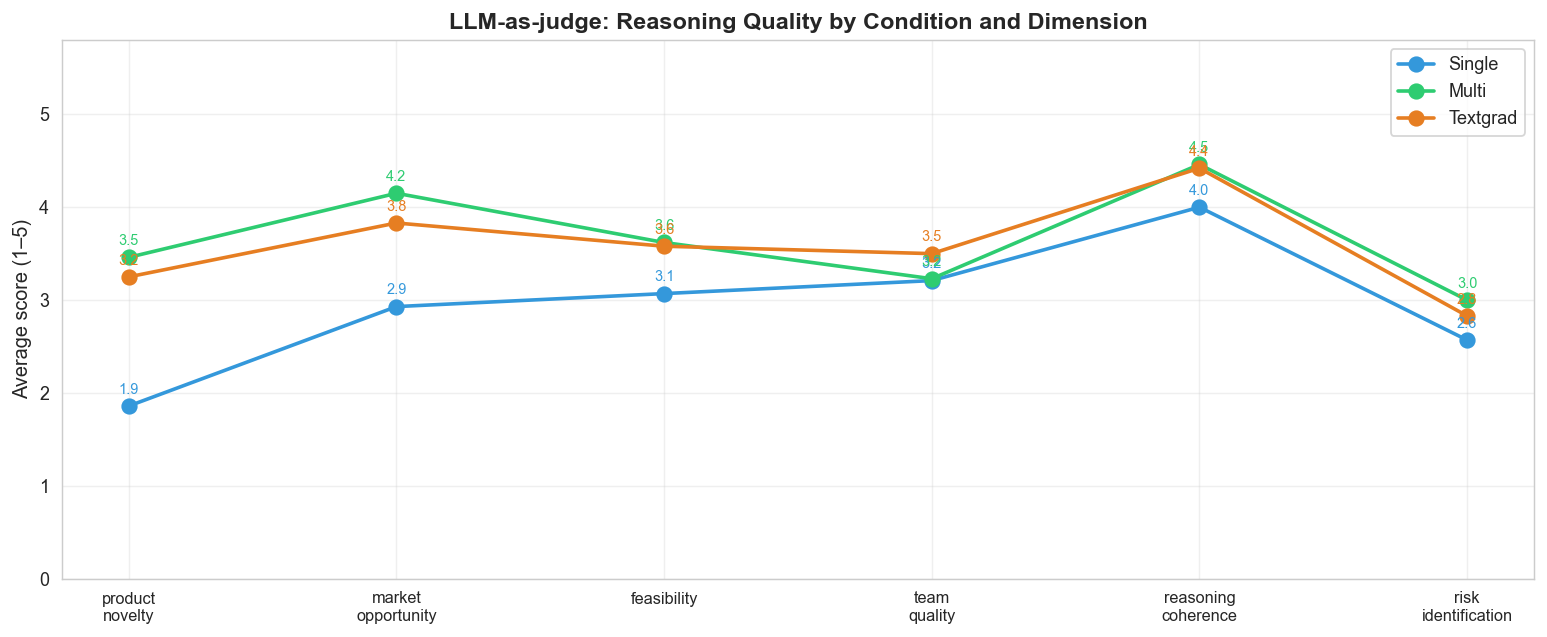

In [95]:
if judge_smry is not None:
    dims = ['product novelty','market opportunity','feasibility',
            'team quality','reasoning coherence','risk identification']
    available_dims = [d for d in dims if d in judge_smry.columns]

    print("Average scores by condition (1–5 scale):\n")
    display(judge_smry[available_dims + ['total_score']].round(2) if 'total_score' in judge_smry.columns
            else judge_smry[available_dims].round(2))

    order = [c for c in ['single','multi','textgrad'] if c in judge_smry.index]
    palette = {'single':'#3498db','multi':'#2ecc71','textgrad':'#e67e22'}

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(available_dims))

    for cond in order:
        vals = [judge_smry.loc[cond, d] if d in judge_smry.columns else 0 for d in available_dims]
        ax.plot(x, vals, 'o-', linewidth=2, markersize=8,
                label=cond.capitalize(), color=palette.get(cond))
        for xi, v in zip(x, vals):
            ax.text(xi, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8,
                    color=palette.get(cond))

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace(' ', '\n') for d in available_dims], fontsize=9)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Average score (1–5)')
    ax.set_title('LLM-as-judge: Reasoning Quality by Condition and Dimension', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No judge results found. Run: python experiments/run_judge_evaluation.py --n_sample 10")

In [96]:
# Per-startup breakdown
if judge_df is not None and not judge_df.empty:
    score_cols = [c for c in judge_df.columns if c.endswith('_score')]
    print("Per-startup scores by condition:\n")
    for obj_id in judge_df['object_id'].unique():
        sub = judge_df[judge_df['object_id'] == obj_id]
        name   = sub['name'].iloc[0]
        target = 'INVEST' if sub['target'].iloc[0] == 1 else 'PASS'
        print(f"{name} (ground truth: {target})")
        for _, row in sub.iterrows():
            scores = '  '.join(f"{c.replace('_score','')[:4]}={int(row[c])}" for c in score_cols if c in row)
            print(f"  [{row['condition']:9s}] decision={row.get('decision','?'):5s}  {scores}  total={int(row['total_score'])}")
        print()


Per-startup scores by condition:

TripUp (ground truth: PASS)
  [single   ] decision=PASS   prod=2  mark=2  feas=4  team=4  reas=4  risk=4  tota=20  total=20
  [multi    ] decision=PASS   prod=2  mark=4  feas=3  team=2  reas=4  risk=4  tota=19  total=19
  [textgrad ] decision=PASS   prod=2  mark=2  feas=3  team=3  reas=4  risk=4  tota=18  total=18

Picnik (ground truth: INVEST)
  [single   ] decision=INVEST  prod=2  mark=4  feas=3  team=2  reas=4  risk=2  tota=17  total=17
  [multi    ] decision=INVEST  prod=3  mark=4  feas=4  team=3  reas=5  risk=2  tota=21  total=21
  [textgrad ] decision=INVEST  prod=3  mark=4  feas=4  team=3  reas=5  risk=2  tota=21  total=21

Paprika Lab (ground truth: INVEST)
  [single   ] decision=INVEST  prod=1  mark=4  feas=2  team=4  reas=4  risk=1  tota=16  total=16
  [multi    ] decision=INVEST  prod=2  mark=4  feas=3  team=4  reas=5  risk=1  tota=19  total=19
  [textgrad ] decision=INVEST  prod=2  mark=4  feas=3  team=4  reas=4  risk=1  tota=18  total=18



## 8. Score gains, radar chart, and progression

In [ ]:
# ── Reload judge summary (safe if section 7 wasn't run) ──────────────────────
try:
    _smry = judge_smry
except NameError:
    _smry = None

if _smry is None:
    path = _pick_judge_file("judge_summary.json")
    _smry = pd.read_json(path) if path else None

DIMS = ['product novelty', 'market opportunity', 'feasibility',
        'team quality', 'reasoning coherence', 'risk identification']
DIMS = [d for d in DIMS if _smry is not None and d in _smry.columns]
ORDER = [c for c in ['single', 'multi', 'textgrad'] if _smry is not None and c in _smry.index]
PALETTE = {'single': '#3498db', 'multi': '#2ecc71', 'textgrad': '#e67e22'}

print(f"Conditions: {ORDER}")
print(f"Dimensions: {DIMS}")
if _smry is not None:
    display(_smry[DIMS + (['total_score'] if 'total_score' in _smry.columns else [])].round(2))

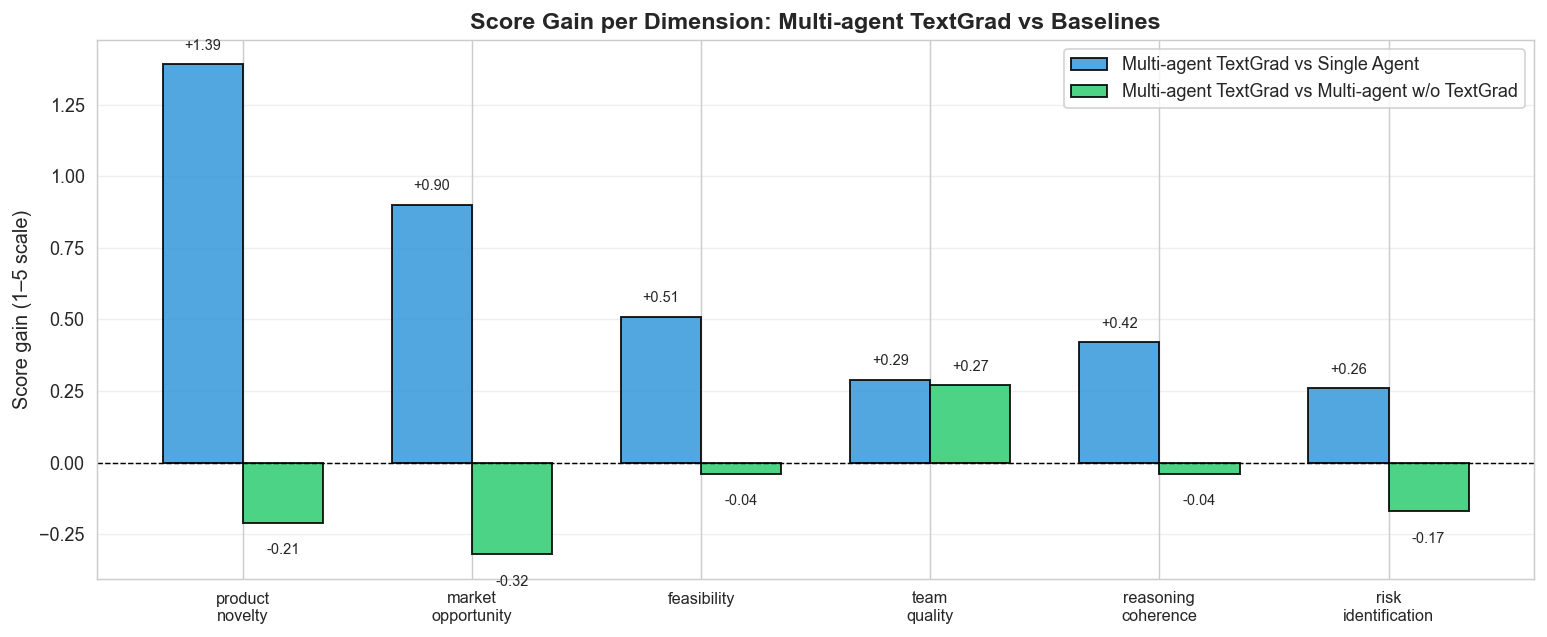

In [98]:
# ── Score gain per dimension ──────────────────────────────────────────────────
if _smry is not None and 'textgrad' in ORDER:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(DIMS))
    width = 0.35

    baseline_labels = {
        'single': 'Multi-agent TextGrad vs Single Agent',
        'multi':  'Multi-agent TextGrad vs Multi-agent w/o TextGrad',
    }
    baselines = [c for c in ['single', 'multi'] if c in ORDER]
    offsets = np.linspace(-width/2 * (len(baselines)-1), width/2 * (len(baselines)-1), len(baselines))

    for offset, base in zip(offsets, baselines):
        deltas = [_smry.loc['textgrad', d] - _smry.loc[base, d] for d in DIMS]
        bars = ax.bar(x + offset, deltas, width, label=baseline_labels[base],
                      color=PALETTE[base], alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar in bars:
            h = bar.get_height()
            ypos = h + 0.04 if h >= 0 else h - 0.12
            ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{h:+.2f}',
                    ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace(' ', '\n') for d in DIMS], fontsize=9)
    ax.set_ylabel('Score gain (1–5 scale)')
    ax.set_title('Score Gain per Dimension: Multi-agent TextGrad vs Baselines', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

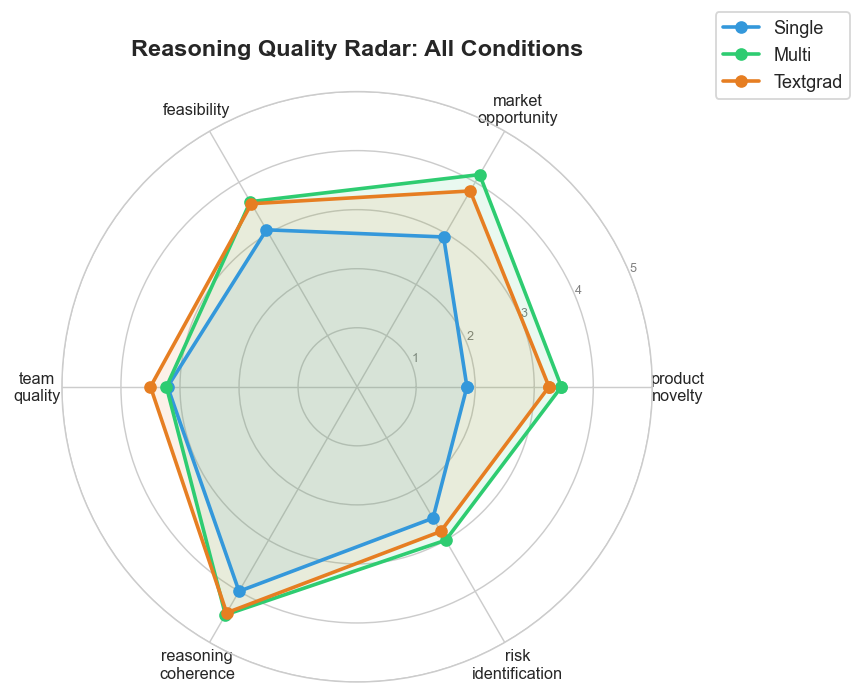

In [99]:
# ── Radar chart ───────────────────────────────────────────────────────────────
if _smry is not None:
    N = len(DIMS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

    for cond in ORDER:
        vals = [_smry.loc[cond, d] for d in DIMS] + [_smry.loc[cond, DIMS[0]]]
        ax.plot(angles, vals, 'o-', linewidth=2, label=cond.capitalize(), color=PALETTE[cond])
        ax.fill(angles, vals, alpha=0.10, color=PALETTE[cond])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d.replace(' ', '\n') for d in DIMS], size=9)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], size=7, color='grey')
    ax.set_title('Reasoning Quality Radar: All Conditions', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()
    plt.show()

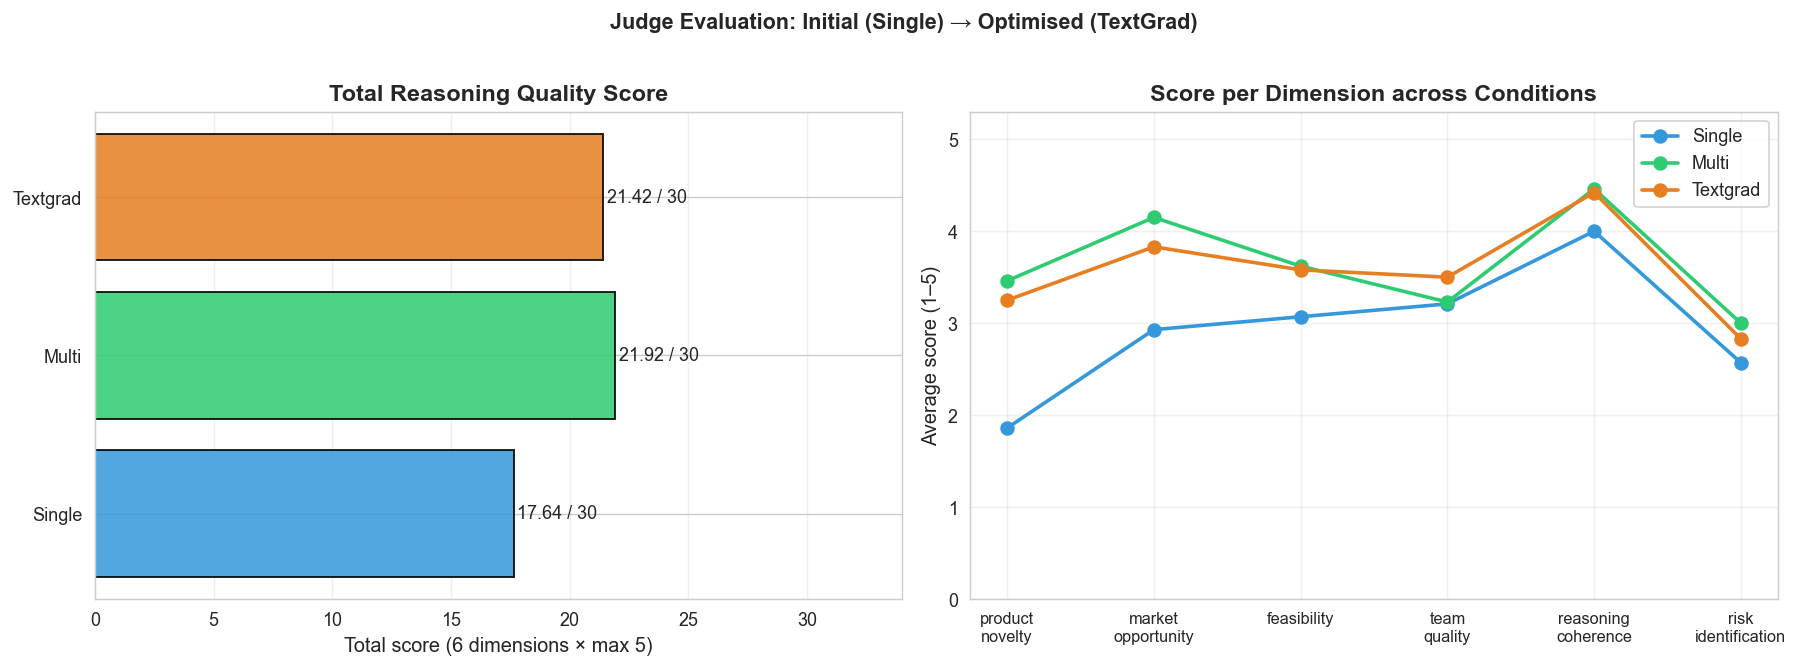

In [100]:
# ── Initial vs final total scores + per-dimension progression ─────────────────
if _smry is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: total score comparison
    if 'total_score' in _smry.columns:
        totals = [_smry.loc[c, 'total_score'] for c in ORDER]
        colors = [PALETTE[c] for c in ORDER]
        bars = ax1.barh([c.capitalize() for c in ORDER], totals,
                        color=colors, alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar, val in zip(bars, totals):
            ax1.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f} / 30', va='center', fontsize=10)
        ax1.set_xlim(0, 34)
        ax1.set_xlabel('Total score (6 dimensions × max 5)')
        ax1.set_title('Total Reasoning Quality Score', fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)

    # Right: per-dimension score across conditions (line, treating as progression)
    x = np.arange(len(DIMS))
    for cond in ORDER:
        vals = [_smry.loc[cond, d] for d in DIMS]
        ax2.plot(x, vals, 'o-', linewidth=2, label=cond.capitalize(),
                 color=PALETTE[cond], markersize=7)

    ax2.set_xticks(x)
    ax2.set_xticklabels([d.replace(' ', '\n') for d in DIMS], fontsize=9)
    ax2.set_ylim(0, 5.3)
    ax2.set_ylabel('Average score (1–5)')
    ax2.set_title('Score per Dimension across Conditions', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Judge Evaluation: Initial (Single) → Optimised (TextGrad)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()